In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import AutoReg

In [2]:
listings = pd.read_csv('listings.csv')
listings.head()
# listings['neighbourhood'].unique()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2384,Hyde Park - Walk to University of Chicago,2613,Rebecca,NaN,Hyde Park,41.787900,-87.587800,Private room,119.0,3,257,2025-08-07,1.97,1,348,10,R17000015609
1,7126,Tiny Studio Apartment 94 Walk Score,17928,Sarah,NaN,West Town,41.901660,-87.680210,Entire home/apt,89.0,2,595,2025-09-01,3.01,1,302,47,R24000114046
2,10945,The Biddle House (#1),33004,At Home Inn,NaN,Lincoln Park,41.911960,-87.639810,Entire home/apt,203.0,4,129,2025-09-06,0.93,6,325,24,2209984
3,12140,Lincoln Park Guest House,46734,Shar And Robert,NaN,Lincoln Park,41.923570,-87.649470,Private room,339.0,2,19,2025-09-07,0.15,1,156,3,2398451
4,28749,Quirky Bucktown Loft w/ Parking No Parties,27506,Lauri,NaN,Logan Square,41.920226,-87.679613,Entire home/apt,258.0,2,265,2025-09-01,1.47,1,74,37,R24000113825


In [3]:
reviews = pd.read_csv('reviews.csv')
reviews.head()

,listing_id,date
0,2384,2015-01-09
1,2384,2015-03-24
2,2384,2015-04-30
3,2384,2015-05-04
4,2384,2015-05-10


In [4]:
neighbourhoods = pd.read_csv('neighbourhoods.csv')
neighbourhoods.head()

,neighbourhood_group,neighbourhood
0,NaN,Albany Park
1,NaN,Archer Heights
2,NaN,Armour Square
3,NaN,Ashburn
4,NaN,Auburn Gresham


In [5]:
reviews['date'] = pd.to_datetime(reviews['date'])
# must have at least 1 review
activity = reviews.groupby('listing_id')['date'].agg(['min', 'max']).reset_index()
activity.columns = ['listing_id', 'first_review', 'last_review']
print(f"list with reviews: {len(activity)}")
print(f"total list in listings.csv: {len(listings)}")
print(f"no reviews: {len(listings)- activity['listing_id'].isin(listings['id']).sum()}")
activity.head()

list with reviews: 6978
total list in listings.csv: 8663
no reviews: 1685


,listing_id,first_review,last_review
0,2384,2015-01-09,2025-08-07
1,7126,2009-07-03,2025-09-01
2,10945,2014-04-28,2025-09-06
3,12140,2015-06-29,2025-09-07
4,28749,2010-12-01,2025-09-01


In [6]:
quarters = pd.period_range(start=activity['first_review'].min().to_period('Q'), end=activity['last_review'].max().to_period('Q'), freq='Q')
counts = []
# add if first/last review 
for q in quarters:
    q_start = q.start_time.tz_localize(None)
    q_end = q.end_time.tz_localize(None)
    n_active = 0
    for index, listing in activity.iterrows():
        if listing['first_review'] <= q_end and listing['last_review'] >= q_start:
            n_active += 1
    counts.append({'quarter': str(q), 'active_listings': n_active})
quarterly = pd.DataFrame(counts)
quarterly['quarter'] = pd.PeriodIndex(quarterly['quarter'], freq='Q')
quarterly

,quarter,active_listings
0,2009Q3,1
1,2009Q4,1
2,2010Q1,1
3,2010Q2,1
4,2010Q3,1
...,...,...
60,2024Q3,4494
61,2024Q4,4633
62,2025Q1,4677
63,2025Q2,5202


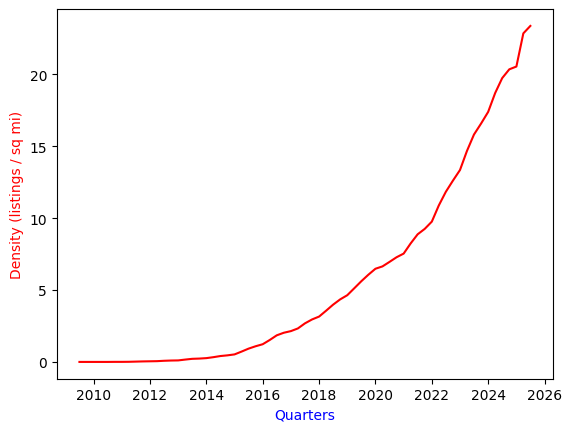

In [7]:
chicago_sqmi = 227.63

quarterly['density'] = quarterly['active_listings'] / chicago_sqmi

plt.plot(quarterly['quarter'].dt.to_timestamp(), quarterly['density'], color='red')
plt.ylabel('Density (listings / sq mi)', color='red')
plt.xlabel('Quarters', color='blue')

plt.show()

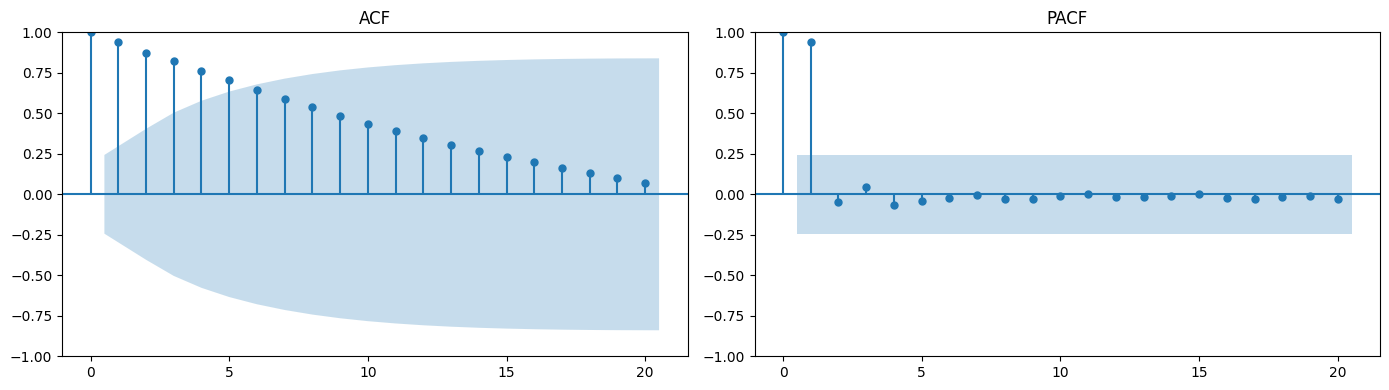

In [8]:
density = quarterly.set_index('quarter')['density']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(density, lags=20, ax=axes[0], title='ACF')
plot_pacf(density, lags=20, ax=axes[1], title='PACF')
plt.tight_layout()
plt.show()

In [9]:
ar_model = AutoReg(density, lags=4).fit()
print(ar_model.summary())

                            AutoReg Model Results                             
Dep. Variable:                density   No. Observations:                   65
Model:                     AutoReg(4)   Log Likelihood                  -4.190
Method:               Conditional MLE   S.D. of innovations              0.259
Date:                Thu, 12 Mar 2026   AIC                             20.380
Time:                        16:43:18   BIC                             33.046
Sample:                    09-30-2010   HQIC                            25.344
                         - 09-30-2025                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1053      0.049      2.156      0.031       0.010       0.201
density.L1     0.8479      0.145      5.848      0.000       0.564       1.132
density.L2     0.0326      0.262      0.124      0.9